##Baseline

Data

In [ ]:
!pip install -U transformers datasets accelerate evaluate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 140.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 19.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
!pip uninstall -y wandb


Found existing installation: wandb 0.23.0
Uninstalling wandb-0.23.0:
  Successfully uninstalled wandb-0.23.0


In [ ]:
!pip install transformers datasets accelerate evaluate scikit-learn arabert


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 12.7 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=dcccaf529f0e4907a52c6bb61b408aa9ad2d3405c23e0de015f4cf3a2289effd
  Stored in directory: /root/.cache/pip/wheels/bb/f1/26/f9002669ef6ad80a3c9f1b22880b35d9b4c6650011acee0523
Successfully built emoji


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import torch
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# Choose Arabic model (similar to ArBanking77 paper)
MODEL_NAME = "aubmindlab/bert-base-arabertv2"  # AraBERTv2
NUM_LABELS = 77
MAX_LEN = 64


Load Train / Validation / Test CSV files

In [ ]:
# Load the training data
train_df = pd.read_csv("/content/Banking77_Arabized_MSA_PAL_train.csv")
# Load the validation data
val_df   = pd.read_csv("/content/Banking77_Arabized_MSA_PAL_val.csv")

# Load the test data (MSA version)
test_df  = pd.read_csv("/content/Banking77_Arabized_MSA_test.csv")

# NOTE:
# If we want to evaluate on the PAL version instead, uncomment this:
# test_df_pal = pd.read_csv("data/Banking77_Arabized_PAL_test.csv")


Convert Pandas DataFrames to HuggingFace DatasetDict

In [ ]:
#  Convert the DataFrames into a HuggingFace DatasetDict
from datasets import Dataset, DatasetDict
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})


Convert DatasetSplits Back to Pandas

In [ ]:

# Convert DatasetDict splits back to Pandas (for inspection/debugging)
train_df = pd.DataFrame(dataset["train"])
val_df   = pd.DataFrame(dataset["validation"])
test_df  = pd.DataFrame(dataset["test"])

# Print shapes of each dataset
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Preview first rows of train set
train_df.head()


Train shape: (21559, 2)
Validation shape: (2464, 2)
Test shape: (3574, 2)


,label,text
0,وصول البطاقة,ما زلت أنتظر بطاقتي؟
1,وصول البطاقة,ماذا أفعل إذا لم تصل بطاقتي بعد أسبوعين؟
2,وصول البطاقة,انا أنتظر منذ أكثر من أسبوع. هل ما زالت البطاق...
3,وصول البطاقة,هل يمكنني تتبع بطاقتي أثناء عملية التسليم؟
4,وصول البطاقة,كيف أعرف إذا ما كنت سأحصل على بطاقتي ، أو إذا ...


In [ ]:
# Inspect the structure of the training dataset

# Show first few rows to verify columns (label + text)
print(train_df.head())


          label                                               text
0  وصول البطاقة                               ما زلت أنتظر بطاقتي؟
1  وصول البطاقة           ماذا أفعل إذا لم تصل بطاقتي بعد أسبوعين؟
2  وصول البطاقة  انا أنتظر منذ أكثر من أسبوع. هل ما زالت البطاق...
3  وصول البطاقة         هل يمكنني تتبع بطاقتي أثناء عملية التسليم؟
4  وصول البطاقة  كيف أعرف إذا ما كنت سأحصل على بطاقتي ، أو إذا ...


In [ ]:
# Print column names to ensure correct formatting
print(train_df.columns)

Index(['label', 'text'], dtype='object')


Encode Labels Using a Consistent LabelEncoder

In [ ]:
#  Fit a LabelEncoder on ALL labels (train + validation + test)
#    This ensures the same label → ID mapping across all splits.


from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Combine all labels to ensure a unified mapping
all_labels = pd.concat([train_df['label'], val_df['label'], test_df['label']])

# Initialize and fit the label encoder
le = LabelEncoder()
le.fit(all_labels)

# Transform labels in each split
train_df['label_id'] = le.transform(train_df['label'])
val_df['label_id']   = le.transform(val_df['label'])
test_df['label_id']  = le.transform(test_df['label'])

# Extract label list and the number of unique intents
label_list = list(le.classes_)
num_labels = len(label_list)

# Display summary
print("Number of intents:", num_labels)
print("Example mapping:", {i: label_list[i] for i in range(min(5, num_labels))})


Number of intents: 77
Example mapping: {0: 'آبل باي أو جوجل باي', 1: 'إرجاع الدفع بالبطاقة؟', 2: 'إعادة الشحن عن طريق رسوم التحويل المصرفي', 3: 'إلغاء التحويل', 4: 'ابتلاع البطاقة'}


In [ ]:
NUM_LABELS = num_labels


In [ ]:

#  Convert cleaned Pandas DataFrames into HuggingFace Dataset objects
#    (Only keep `text` and `label_id` columns)


from datasets import Dataset, DatasetDict

# Create Dataset objects from each split
train_ds = Dataset.from_pandas(train_df[['text', 'label_id']])
val_ds   = Dataset.from_pandas(val_df[['text', 'label_id']])
test_ds  = Dataset.from_pandas(test_df[['text', 'label_id']])

# Combine all splits into a single DatasetDict
dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

# Display dataset structure
dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label_id'],
        num_rows: 21559
    })
    validation: Dataset({
        features: ['text', 'label_id'],
        num_rows: 2464
    })
    test: Dataset({
        features: ['text', 'label_id'],
        num_rows: 3574
    })
})

okenization & Dataset Encoding

In [ ]:

#  Load tokenizer and preprocess dataset


from transformers import AutoTokenizer

# Load the tokenizer from the pretrained model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Preprocessing function applied to each dataset split
def preprocess_function(examples):
    """
    Tokenize the input text.
    - truncation=True: cut text to the max length
    - max_length=MAX_LEN: fixed maximum sequence length
    """

    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN
    )

# Apply tokenization across the dataset (batched for speed)
encoded_dataset = dataset.map(preprocess_function, batched=True)

# Rename label column to 'labels' so HuggingFace Trainer recognizes it
encoded_dataset = encoded_dataset.rename_column("label_id", "labels")

# Set dataset format for PyTorch (return tensors for training)
encoded_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/21559 [00:00<?, ? examples/s]

Map:   0%|          | 0/2464 [00:00<?, ? examples/s]

Map:   0%|          | 0/3574 [00:00<?, ? examples/s]

Build Model (BERT Classification Head)

In [ ]:

#  Load the model for sequence classification


from transformers import AutoModelForSequenceClassification

# Create mappings for label <-> id (required for correct decoding)
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

# Load pretrained model with the correct number of labels
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Define Metrics (Accuracy + Macro F1)

In [ ]:

#  Metrics: Accuracy + Macro F1

import evaluate
from sklearn.metrics import f1_score
import numpy as np

# Load HuggingFace accuracy metric
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """
    Compute accuracy and macro-F1 for evaluation.
    eval_pred = (logits, true_labels)
    """
    logits, labels = eval_pred

    # Convert logits → predicted class IDs
    preds = np.argmax(logits, axis=-1)

    # Compute accuracy
    acc = accuracy_metric.compute(
        predictions=preds,
        references=labels
    )["accuracy"]

    # Compute macro F1 (equal weight for each class)
    macro_f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "macro_f1": macro_f1
    }


Training Arguments (Hyperparameters)

In [ ]:

# Training hyperparameters

batch_size = 16          # Number of samples processed in parallel
epochs = 5               # Total passes over the training dataset
lr = 2e-5                # Learning rate (recommended for BERT models)

from transformers import TrainingArguments

# Configuration for model training
training_args = TrainingArguments(
    output_dir="./arabank77_model",      # Folder to save checkpoints + logs
    learning_rate=lr,                    # How fast the model updates weights
    per_device_train_batch_size=batch_size,   # Train batch size per GPU
    per_device_eval_batch_size=batch_size,    # Eval batch size per GPU
    num_train_epochs=epochs,             # Total training epochs
    weight_decay=0.01,                   # L2 regularization
    logging_steps=50,                    # Print logs every 50 steps
    report_to="none",                    # Disable WandB / HF logging
)


Trainer Setup & Start Training

In [ ]:

#Trainer: Handles the full training loop


from transformers import Trainer

trainer = Trainer(
    model=model,                               # Our fine-tuned BERT model
    args=training_args,                         # Training hyperparameters
    train_dataset=encoded_dataset["train"],     # Training data
    eval_dataset=encoded_dataset["validation"], # Validation data
    tokenizer=tokenizer,                        # Tokenizer used for padding
    compute_metrics=compute_metrics,            # Function to compute accuracy/F1
)

# Start fine-tuning the model
trainer.train()


/tmp/ipython-input-3830579464.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.


Step,Training Loss
50,4.365000
100,4.288100
150,4.143900
200,3.964900
250,3.805900
300,3.599600
350,3.431000
400,3.229200
450,3.039700
500,2.889400


TrainOutput(global_step=6740, training_loss=0.8029425566557253, metrics={'train_runtime': 1256.3093, 'train_samples_per_second': 85.803, 'train_steps_per_second': 5.365, 'total_flos': 2164510047148380.0, 'train_loss': 0.8029425566557253, 'epoch': 5.0})

Evaluate Model on Test Set

In [ ]:
#  Evaluate the fine-tuned model on the TEST split
results = trainer.evaluate(encoded_dataset["test"])
results


{'eval_loss': 0.37515512108802795,
 'eval_accuracy': 0.9057078903189704,
 'eval_macro_f1': 0.9050907618772291,
 'eval_runtime': 8.1662,
 'eval_samples_per_second': 437.657,
 'eval_steps_per_second': 27.43,
 'epoch': 5.0}

Detailed Classification Report (Bordered Table)

In [ ]:

# Generate a detailed classification report as a bordered table


from sklearn.metrics import classification_report
import numpy as np
from tabulate import tabulate   # Used to print a nicely formatted table

# 1) Run prediction on the test set
pred = trainer.predict(encoded_dataset["test"])
y_pred = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

# 2) Get the standard sklearn classification report as a dict
report = classification_report(
    y_true,
    y_pred,
    target_names=label_list,
    digits=3,
    output_dict=True
)

# 3) Convert the report into a table (list of rows)
table_data = []
for label in label_list:
    row = [
        label,
        report[label]["precision"],
        report[label]["recall"],
        report[label]["f1-score"],
        report[label]["support"],
    ]
    table_data.append(row)

# 4) Print the table with borders
print(
    tabulate(
        table_data,
        headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
        tablefmt="grid",   # Draws a full ASCII table with borders
        floatfmt=".3f"     # Format floating numbers with 3 decimal places
    )
)


+-------------------------------------------------+-------------+----------+------------+-----------+
| Class                                           |   Precision |   Recall |   F1-Score |   Support |
+=================================================+=============+==========+============+===========+
| آبل باي أو جوجل باي                             |       0.976 |    0.952 |      0.964 |    42.000 |
+-------------------------------------------------+-------------+----------+------------+-----------+
| إرجاع الدفع بالبطاقة؟                           |       0.896 |    0.935 |      0.915 |    46.000 |
+-------------------------------------------------+-------------+----------+------------+-----------+
| إعادة الشحن عن طريق رسوم التحويل المصرفي        |       0.956 |    0.811 |      0.878 |    53.000 |
+-------------------------------------------------+-------------+----------+------------+-----------+
| إلغاء التحويل                                   |       1.000 |    0.950 |      

In [ ]:
save_dir = "./arbank77_model_final"

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)


('./arbank77_model_final/tokenizer_config.json',
 './arbank77_model_final/special_tokens_map.json',
 './arbank77_model_final/vocab.txt',
 './arbank77_model_final/added_tokens.json',
 './arbank77_model_final/tokenizer.json')

In [ ]:
import torch

# Select the same device the model was trained on (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the fine-tuned model to the selected device
model.to(device)


def predict_intent(text):
    # Put model in evaluation mode (disables dropout, etc.)
    model.eval()

    # Tokenize the input text and prepare tensors
    inputs = tokenizer(
        text,
        return_tensors="pt",   # return PyTorch tensors
        truncation=True,       # cut long text
        padding=True           # pad shorter text
    ).to(device)               # <<< Move inputs to the same device as the model

    # Disable gradient calculation to speed up inference
    with torch.no_grad():
        outputs = model(**inputs)   # Forward pass through the model

    # Get the predicted class ID (argmax over logits)
    pred_id = outputs.logits.argmax(-1).item()

    # Convert numeric ID → text label
    return id2label[pred_id]


# ---- Example predictions ----
print(predict_intent("متى توصل بطاقتي الجديدة؟"))
print(predict_intent("ابغى اعرف رصيدي الحالي"))
print(predict_intent("كيف ارفع حد التحويل اليومي؟"))


وصول البطاقة
التعبئة عن طريق البطاقة
حدود التعبئة


 Low-Resource Experiments for AraBERTv2

In [ ]:
MODEL_NAME_ARABERT = "aubmindlab/bert-base-arabertv2"


In [ ]:
from copy import deepcopy
from datasets import DatasetDict

def train_eval_arabert_on_subset(train_subset, val_dataset, test_dataset, subset_name):
    """
    Fine-tune AraBERTv2 on a subset of the training data and evaluate on test.
    Returns (results_dict, subset_name).
    """
    print(f"\n===== Training AraBERTv2 on {subset_name} of training data =====")
    print(f"Train size: {len(train_subset)}  |  Val size: {len(val_dataset)}  |  Test size: {len(test_dataset)}")

    # Re-initialize model for a clean run
    model_arabert_subset = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME_ARABERT,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )

    # Same training args as baseline (+output_dir)
    training_args_arabert_subset = TrainingArguments(
        output_dir=f"./results_arabert_{subset_name}",
        learning_rate=4e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        logging_steps=100,
        save_total_limit=1
        # evaluation_strategy, load_best_model_at_end, metric_for_best_model
    )

    trainer_arabert_subset = Trainer(
        model=model_arabert_subset,
        args=training_args_arabert_subset,
        train_dataset=train_subset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer_arabert_subset.train()

    # Evaluate on test set
    print(f"\n===== Evaluation on TEST ({subset_name}) =====")
    test_results = trainer_arabert_subset.evaluate(test_dataset)
    print(test_results)
    return test_results, subset_name


# --------- Create 20% and 50% subsets from TRAIN ---------

full_train = encoded_dataset["train"]
full_train_shuffled = full_train.shuffle(seed=42)

n_train = len(full_train)
n_20 = int(0.20 * n_train)
n_50 = int(0.50 * n_train)

train_20 = full_train_shuffled.select(range(n_20))
train_50 = full_train_shuffled.select(range(n_50))
train_100 = full_train  # full data

val_dataset = encoded_dataset["validation"]
test_dataset = encoded_dataset["test"]

# --------- Run experiments ---------
results_20, name_20 = train_eval_arabert_on_subset(train_20, val_dataset, test_dataset, "20pct")
results_50, name_50 = train_eval_arabert_on_subset(train_50, val_dataset, test_dataset, "50pct")
results_100, name_100 = train_eval_arabert_on_subset(train_100, val_dataset, test_dataset, "100pct")

# --------- Collect into a small table (Table 7-style) ---------

import pandas as pd

lowres_table = pd.DataFrame({
    "% of data": ["20%", "50%", "100%"],
    "Test Accuracy": [
        results_20["eval_accuracy"],
        results_50["eval_accuracy"],
        results_100["eval_accuracy"],
    ],
    "Test Macro F1": [
        results_20["eval_macro_f1"],
        results_50["eval_macro_f1"],
        results_100["eval_macro_f1"],
    ]
})

print("\nLow-Resource Results for AraBERTv2 (Test set):")
print(lowres_table)



===== Training AraBERTv2 on 20pct of training data =====
Train size: 4311  |  Val size: 2464  |  Test size: 3574


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2224428067.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_arabert_subset = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.


Step,Training Loss
100,4.286300
200,4.260400
300,4.325000
400,4.310500
500,4.338500
600,4.319500
700,4.310000
800,4.313100
900,4.297700
1000,4.307300



===== Evaluation on TEST (20pct) =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

{'eval_loss': 0.46597981452941895, 'eval_accuracy': 0.8850027979854505, 'eval_macro_f1': 0.883743741465433, 'eval_runtime': 7.9355, 'eval_samples_per_second': 450.379, 'eval_steps_per_second': 28.227, 'epoch': 5.0}

===== Training AraBERTv2 on 100pct of training data =====
Train size: 21559  |  Val size: 2464  |  Test size: 3574


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2224428067.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_arabert_subset = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.


Step,Training Loss
100,4.253000
200,3.635800
300,2.962300
400,2.389600
500,1.928700
600,1.601000
700,1.375500
800,1.152900
900,1.042900
1000,0.909200



===== Evaluation on TEST (100pct) =====


{'eval_loss': 0.4016804099082947, 'eval_accuracy': 0.9093452714045887, 'eval_macro_f1': 0.9086199419677959, 'eval_runtime': 8.1796, 'eval_samples_per_second': 436.94, 'eval_steps_per_second': 27.385, 'epoch': 5.0}

Low-Resource Results for AraBERTv2 (Test set):
  % of data  Test Accuracy  Test Macro F1
0       20%       0.014550       0.000372
1       50%       0.885003       0.883744
2      100%       0.909345       0.908620


Simple Noise Functions (sim_c, sim_s, sim_k)

In [29]:


import random

arabic_letters = "ابتثجحخدذرزسشصضطظعغفقكلمنهوي"

keyboard_neighbors = {
    "ق": ["ث", "ف"],
    "ف": ["ق", "غ"],
    "غ": ["ف", "ع"],
    "ع": ["غ", "ه"],
    "ه": ["ع", "خ"],
    "خ": ["ه", "ح"],
    "ح": ["خ", "ج"],
    "ج": ["ح", "ي"],
    "ي": ["ج", "ب"],
    "ب": ["ي", "ل"],
    "ل": ["ب", "ا"],
    # يمكنك توسيع الخريطة لو حبيتي
}

def sim_c_char_noise(text, prob=0.05):
    """
    Character-level noise: random delete or duplicate of characters.
    Inspired by sim_c in the paper (not identical).
    """
    chars = list(text)
    new_chars = []
    for ch in chars:
        r = random.random()
        if r < prob / 2:
            # delete char (skip)
            continue
        new_chars.append(ch)
        if prob/2 <= r < prob:
            # duplicate char once
            new_chars.append(ch)
    return "".join(new_chars)


def sim_s_spelling_noise(text, prob=0.05):
    """
    Simple spelling noise: randomly swap adjacent characters or repeat vowels.
    Inspired by sim_s.
    """
    chars = list(text)
    i = 0
    new_chars = []
    while i < len(chars):
        if i < len(chars) - 1 and random.random() < prob:
            # swap this char with the next one
            new_chars.append(chars[i+1])
            new_chars.append(chars[i])
            i += 2
        else:
            ch = chars[i]
            new_chars.append(ch)
            # sometimes repeat if it's similar to a vowel
            if ch in "ايو" and random.random() < prob:
                new_chars.append(ch)
            i += 1
    return "".join(new_chars)


def sim_k_keyboard_noise(text, prob=0.05):
    """
    Keyboard noise: replace some characters with neighbors on the Arabic keyboard.
    Inspired by sim_k.
    """
    new_chars = []
    for ch in text:
        if ch in keyboard_neighbors and random.random() < prob:
            new_chars.append(random.choice(keyboard_neighbors[ch]))
        else:
            new_chars.append(ch)
    return "".join(new_chars)


Build Augmented Training Sets (20% data)

In [34]:

# We'll reuse train_20 from the low-resource section
raw_train_20 = dataset["train"].shuffle(seed=42).select(range(n_20))

def add_noise_to_example(example, mode="sim_c"):
    text = example["text"]

    if mode == "sim_c":
        noisy = sim_c_char_noise(text)
    elif mode == "sim_s":
        noisy = sim_s_spelling_noise(text)
    elif mode == "sim_k":
        noisy = sim_k_keyboard_noise(text)
    else:
        noisy = text

    return {
        "text": noisy,
        "label_id": example["label_id"]
    }



train_20_sim_c = raw_train_20.map(lambda ex: add_noise_to_example(ex, mode="sim_c"))
train_20_sim_s = raw_train_20.map(lambda ex: add_noise_to_example(ex, mode="sim_s"))
train_20_sim_k = raw_train_20.map(lambda ex: add_noise_to_example(ex, mode="sim_k"))

print(len(raw_train_20), len(train_20_sim_c), len(train_20_sim_s), len(train_20_sim_k))


Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

4311 4311 4311 4311


 Re-tokenize the noisy versions using the same tokenize_function used before

In [36]:
# Re-tokenize the noisy versions using the same tokenize_function you used before

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=77,
    )

encoded_train_20_clean   = train_20.map(tokenize_function, batched=True)
encoded_train_20_sim_c   = train_20_sim_c.map(tokenize_function, batched=True)
encoded_train_20_sim_s   = train_20_sim_s.map(tokenize_function, batched=True)
encoded_train_20_sim_k   = train_20_sim_k.map(tokenize_function, batched=True)

# لازم نضمن أن "labels" موجودة بنفس الشكل
for ds in [encoded_train_20_clean, encoded_train_20_sim_c, encoded_train_20_sim_s, encoded_train_20_sim_k]:
    ds = ds.remove_columns([c for c in ds.column_names if c not in ["input_ids", "attention_mask", "labels"]])


Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

 Train AraBERTv2 on clean vs augmented 20% data

In [39]:


# Reuse the same n_20 computed earlier in low-resource experiments
raw_train_20 = dataset["train"].shuffle(seed=42).select(range(n_20))
# raw_train_20 contains columns: ["text", "label_id"]

def add_noise_to_example(example, mode="sim_c"):
    """
    Apply artificial noise to a single training example.
    mode = sim_c: character-level noise
    mode = sim_s: spelling noise
    mode = sim_k: keyboard noise
    """
    text = example["text"]

    if mode == "sim_c":
        noisy = sim_c_char_noise(text)
    elif mode == "sim_s":
        noisy = sim_s_spelling_noise(text)
    elif mode == "sim_k":
        noisy = sim_k_keyboard_noise(text)
    else:
        noisy = text  # fallback: no noise

    # Important: preserve label_id since our dataset uses this column name
    return {
        "text": noisy,
        "label_id": example["label_id"],
    }

# Build different noisy versions of the same 20% subset
train_20_clean = raw_train_20
train_20_sim_c = raw_train_20.map(lambda ex: add_noise_to_example(ex, mode="sim_c"))
train_20_sim_s = raw_train_20.map(lambda ex: add_noise_to_example(ex, mode="sim_s"))
train_20_sim_k = raw_train_20.map(lambda ex: add_noise_to_example(ex, mode="sim_k"))

print("Dataset Sizes:",
      len(train_20_clean),
      len(train_20_sim_c),
      len(train_20_sim_s),
      len(train_20_sim_k))


# Tokenization — also attach labels to the batch


MAX_LENGTH = 77   # Suitable for ArBanking77 short queries

def tokenize_with_labels(batch):
    """
    Tokenize text and attach the correct 'labels' column.
    The Trainer expects a column called 'labels'.
    """
    enc = tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    # Convert 'label_id' → 'labels'
    enc["labels"] = batch["label_id"]
    return enc

# Tokenize all versions
encoded_train_20_clean = train_20_clean.map(tokenize_with_labels, batched=True)
encoded_train_20_sim_c = train_20_sim_c.map(tokenize_with_labels, batched=True)
encoded_train_20_sim_s = train_20_sim_s.map(tokenize_with_labels, batched=True)
encoded_train_20_sim_k = train_20_sim_k.map(tokenize_with_labels, batched=True)

# Keep only columns required by Trainer
keep_cols = ["input_ids", "attention_mask", "labels"]

encoded_train_20_clean = encoded_train_20_clean.remove_columns(
    [c for c in encoded_train_20_clean.column_names if c not in keep_cols]
)
encoded_train_20_sim_c = encoded_train_20_sim_c.remove_columns(
    [c for c in encoded_train_20_sim_c.column_names if c not in keep_cols]
)
encoded_train_20_sim_s = encoded_train_20_sim_s.remove_columns(
    [c for c in encoded_train_20_sim_s.column_names if c not in keep_cols]
)
encoded_train_20_sim_k = encoded_train_20_sim_k.remove_columns(
    [c for c in encoded_train_20_sim_k.column_names if c not in keep_cols]
)

print("Final Columns (clean):", encoded_train_20_clean.column_names)


Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Shapes raw: 4311 4311 4311 4311


Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4311 [00:00<?, ? examples/s]

Cols clean: ['input_ids', 'attention_mask', 'labels']


In [60]:

# Rebuild aug_table (20% augmentation results)
# Uses the outputs: res_20_clean, res_20_sim_c, res_20_sim_s, res_20_sim_k

import pandas as pd

aug_table = pd.DataFrame({
    "Train 20% Variant": ["clean", "sim_c", "sim_s", "sim_k"],
    "Test Accuracy": [
        res_20_clean["eval_accuracy"],
        res_20_sim_c["eval_accuracy"],
        res_20_sim_s["eval_accuracy"],
        res_20_sim_k["eval_accuracy"],
    ],
    "Test Macro F1": [
        res_20_clean["eval_macro_f1"],
        res_20_sim_c["eval_macro_f1"],
        res_20_sim_s["eval_macro_f1"],
        res_20_sim_k["eval_macro_f1"],
    ]
})

print("Augmentation table (20% training data):")
print(aug_table)


Augmentation table (20% training data):
  Train 20% Variant  Test Accuracy  Test Macro F1
0             clean       0.780918       0.772154
1             sim_c       0.730834       0.713012
2             sim_s       0.665081       0.635273
3             sim_k       0.755736       0.739837


In [40]:
res_20_clean  = train_eval_arabert_20_variant(encoded_train_20_clean, "clean")
res_20_sim_c  = train_eval_arabert_20_variant(encoded_train_20_sim_c, "sim_c")
res_20_sim_s  = train_eval_arabert_20_variant(encoded_train_20_sim_s, "sim_s")
res_20_sim_k  = train_eval_arabert_20_variant(encoded_train_20_sim_k, "sim_k")



==== AraBERTv2 20% (clean) ====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3104730052.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.


Step,Training Loss
100,4.342000
200,4.012400
300,3.357200
400,2.735800
500,2.364800
600,1.921500
700,1.605700
800,1.403000
900,1.149600
1000,1.025400


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'eval_loss': 1.119254469871521, 'eval_accuracy': 0.780917739227756, 'eval_macro_f1': 0.7721539400238099, 'eval_runtime': 8.1567, 'eval_samples_per_second': 438.165, 'eval_steps_per_second': 27.462, 'epoch': 5.0}

==== AraBERTv2 20% (sim_c) ====


...

Step,Training Loss
100,4.304300
200,4.093500
300,3.769400
400,3.314900
500,3.036700
600,2.596400
700,2.295600
800,2.128900
900,1.783400
1000,1.658200


{'eval_loss': 1.6189403533935547, 'eval_accuracy': 0.6650811415780638, 'eval_macro_f1': 0.6352725258735386, 'eval_runtime': 8.107, 'eval_samples_per_second': 440.856, 'eval_steps_per_second': 27.631, 'epoch': 5.0}

==== AraBERTv2 20% (sim_k) ====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3104730052.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.


Step,Training Loss
100,4.260500
200,3.798100
300,3.208100
400,2.649000
500,2.370100
600,1.940800
700,1.664800
800,1.465300
900,1.209600
1000,1.094900


{'eval_loss': 1.201854944229126, 'eval_accuracy': 0.7557358701734751, 'eval_macro_f1': 0.7398371683931012, 'eval_runtime': 8.1097, 'eval_samples_per_second': 440.707, 'eval_steps_per_second': 27.621, 'epoch': 5.0}


##Ablation : Model Comparison + Ensembles

In [42]:
# Models: AraBERTv2, MARBERTv2, mBERT
# Ensembles: A+M, A+m, M+m


from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Train MARBERTv2 on the same encoded dataset


MODEL_NAME_MARBERT = "UBC-NLP/MARBERTv2"

marbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_MARBERT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

marbert_args = TrainingArguments(
    output_dir="./results_marbert",
    learning_rate=4e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    save_total_limit=1
    # No evaluation_strategy / load_best_model_at_end (for compatibility)
)

trainer_marbert = Trainer(
    model=marbert_model,
    args=marbert_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("\n===== Training MARBERTv2 =====")
trainer_marbert.train()

print("\n===== Evaluating MARBERTv2 (validation) =====")
marbert_eval = trainer_marbert.evaluate()
print(marbert_eval)



config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2124397603.py:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_marbert = Trainer(


model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.



===== Training MARBERTv2 =====


Step,Training Loss
100,4.288400
200,4.021600
300,3.649500
400,3.351500
500,3.036500
600,2.805000
700,2.570700
800,2.343000
900,2.201200
1000,2.023100



===== Evaluating MARBERTv2 (validation) =====


{'eval_loss': 0.46896496415138245, 'eval_accuracy': 0.8900162337662337, 'eval_macro_f1': 0.8877656129396148, 'eval_runtime': 5.5363, 'eval_samples_per_second': 445.064, 'eval_steps_per_second': 27.816, 'epoch': 5.0}


Train mBERT on the same encoded dataset

In [43]:
MODEL_NAME_MBERT = "bert-base-multilingual-cased"

mbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_MBERT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

mbert_args = TrainingArguments(
    output_dir="./results_mbert",
    learning_rate=4e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    save_total_limit=1
)

trainer_mbert = Trainer(
    model=mbert_model,
    args=mbert_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("\n===== Training mBERT =====")
trainer_mbert.train()

print("\n===== Evaluating mBERT (validation) =====")
mbert_eval = trainer_mbert.evaluate()
print(mbert_eval)


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4052607100.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_mbert = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.



===== Training mBERT =====


Step,Training Loss
100,4.333200
200,4.322300
300,4.304600
400,4.324700
500,4.315000
600,4.326100
700,4.307700
800,4.315600
900,4.315800
1000,4.290100



===== Evaluating mBERT (validation) =====


{'eval_loss': 2.7201428413391113, 'eval_accuracy': 0.2224025974025974, 'eval_macro_f1': 0.12079247380820282, 'eval_runtime': 5.2021, 'eval_samples_per_second': 473.657, 'eval_steps_per_second': 29.604, 'epoch': 5.0}


Print single-model comparison (validation metrics)

In [44]:
# AraBERTv2 metrics are in `results` from the main baseline


print("\n===== Single Model Comparison (Validation) =====")
print("AraBERTv2:", results)
print("MARBERTv2:", marbert_eval)
print("mBERT:", mbert_eval)


===== Single Model Comparison (Validation) =====
AraBERTv2: {'eval_loss': 0.37515512108802795, 'eval_accuracy': 0.9057078903189704, 'eval_macro_f1': 0.9050907618772291, 'eval_runtime': 8.1662, 'eval_samples_per_second': 437.657, 'eval_steps_per_second': 27.43, 'epoch': 5.0}
MARBERTv2: {'eval_loss': 0.46896496415138245, 'eval_accuracy': 0.8900162337662337, 'eval_macro_f1': 0.8877656129396148, 'eval_runtime': 5.5363, 'eval_samples_per_second': 445.064, 'eval_steps_per_second': 27.816, 'epoch': 5.0}
mBERT: {'eval_loss': 2.7201428413391113, 'eval_accuracy': 0.2224025974025974, 'eval_macro_f1': 0.12079247380820282, 'eval_runtime': 5.2021, 'eval_samples_per_second': 473.657, 'eval_steps_per_second': 29.604, 'epoch': 5.0}


 Get predictions (logits) on TEST set

In [45]:
# AraBERTv2: use existing `trainer`
# MARBERTv2: trainer_marbert
# mBERT: trainer_mbert


print("\n===== Getting TEST logits for all models =====")

arabert_preds = trainer.predict(encoded_dataset["test"])
mbert_preds   = trainer_mbert.predict(encoded_dataset["test"])
marbert_preds = trainer_marbert.predict(encoded_dataset["test"])

arabert_logits = arabert_preds.predictions
mbert_logits   = mbert_preds.predictions
marbert_logits = marbert_preds.predictions

# True labels from TEST set
y_true = encoded_dataset["test"]["labels"]




===== Getting TEST logits for all models =====


Ensemble: AraBERTv2 + mBERT

In [46]:

ensemble_logits_arabert_mbert = (arabert_logits + mbert_logits) / 2.0
ensemble_preds_arabert_mbert  = np.argmax(ensemble_logits_arabert_mbert, axis=-1)

ensemble_accuracy_arabert_mbert = accuracy_score(y_true, ensemble_preds_arabert_mbert)
ensemble_macro_f1_arabert_mbert = f1_score(y_true, ensemble_preds_arabert_mbert, average="macro")

print("\n===== Ensemble: AraBERTv2 + mBERT (TEST) =====")
print(f"Accuracy: {ensemble_accuracy_arabert_mbert:.4f}")
print(f"Macro F1: {ensemble_macro_f1_arabert_mbert:.4f}")




===== Ensemble: AraBERTv2 + mBERT (TEST) =====
Accuracy: 0.8979
Macro F1: 0.8972


Ensemble: MARBERTv2 + mBERT

In [47]:

ensemble_logits_marbert_mbert = (marbert_logits + mbert_logits) / 2.0
ensemble_preds_marbert_mbert  = np.argmax(ensemble_logits_marbert_mbert, axis=-1)

ensemble_accuracy_marbert_mbert = accuracy_score(y_true, ensemble_preds_marbert_mbert)
ensemble_macro_f1_marbert_mbert = f1_score(y_true, ensemble_preds_marbert_mbert, average="macro")

print("\n===== Ensemble: MARBERTv2 + mBERT (TEST) =====")
print(f"Accuracy: {ensemble_accuracy_marbert_mbert:.4f}")
print(f"Macro F1: {ensemble_macro_f1_marbert_mbert:.4f}")



===== Ensemble: MARBERTv2 + mBERT (TEST) =====
Accuracy: 0.8386
Macro F1: 0.8371


Ensemble: AraBERTv2 + MARBERTv2

In [48]:

ensemble_logits_arabert_marbert = (arabert_logits + marbert_logits) / 2.0
ensemble_preds_arabert_marbert  = np.argmax(ensemble_logits_arabert_marbert, axis=-1)

ensemble_accuracy_arabert_marbert = accuracy_score(y_true, ensemble_preds_arabert_marbert)
ensemble_macro_f1_arabert_marbert = f1_score(y_true, ensemble_preds_arabert_marbert, average="macro")

print("\n===== Ensemble: AraBERTv2 + MARBERTv2 (TEST) =====")
print(f"Accuracy: {ensemble_accuracy_arabert_marbert:.4f}")
print(f"Macro F1: {ensemble_macro_f1_arabert_marbert:.4f}")



===== Ensemble: AraBERTv2 + MARBERTv2 (TEST) =====
Accuracy: 0.9004
Macro F1: 0.9000


 Build final comparison table (similar to paper model table)

In [49]:

model_comparison_data = {
    "Model/Ensemble": [
        "AraBERTv2",
        "MARBERTv2",
        "mBERT",
        "AraBERTv2 + mBERT",
        "MARBERTv2 + mBERT",
        "AraBERTv2 + MARBERTv2",
    ],
    "Accuracy": [
        results["eval_accuracy"],
        marbert_eval["eval_accuracy"],
        mbert_eval["eval_accuracy"],
        ensemble_accuracy_arabert_mbert,
        ensemble_accuracy_marbert_mbert,
        ensemble_accuracy_arabert_marbert,
    ],
    "Macro F1": [
        results["eval_macro_f1"],
        marbert_eval["eval_macro_f1"],
        mbert_eval["eval_macro_f1"],
        ensemble_macro_f1_arabert_mbert,
        ensemble_macro_f1_marbert_mbert,
        ensemble_macro_f1_arabert_marbert,
    ],
}

model_comparison_df = pd.DataFrame(model_comparison_data)

print("\n===== Model + Ensemble Comparison (TEST) =====")
print(model_comparison_df)


===== Model + Ensemble Comparison (TEST) =====
          Model/Ensemble  Accuracy  Macro F1
0              AraBERTv2  0.905708  0.905091
1              MARBERTv2  0.890016  0.887766
2                  mBERT  0.222403  0.120792
3      AraBERTv2 + mBERT  0.897874  0.897175
4      MARBERTv2 + mBERT  0.838556  0.837118
5  AraBERTv2 + MARBERTv2  0.900392  0.900030


Final Comparison Table + Highlight Best Model

In [52]:


# Create DataFrame again to ensure it's loaded
model_comparison_df = pd.DataFrame({
    "Model/Ensemble": [
        "AraBERTv2",
        "MARBERTv2",
        "mBERT",
        "AraBERTv2 + mBERT",
        "MARBERTv2 + mBERT",
        "AraBERTv2 + MARBERTv2",
    ],
    "Accuracy": [
        results["eval_accuracy"],
        marbert_eval["eval_accuracy"],
        mbert_eval["eval_accuracy"],
        ensemble_accuracy_arabert_mbert,
        ensemble_accuracy_marbert_mbert,
        ensemble_accuracy_arabert_marbert,
    ],
    "Macro F1": [
        results["eval_macro_f1"],
        marbert_eval["eval_macro_f1"],
        mbert_eval["eval_macro_f1"],
        ensemble_macro_f1_arabert_mbert,
        ensemble_macro_f1_marbert_mbert,
        ensemble_macro_f1_arabert_marbert,
    ],
})

# Add Best Accuracy & Best F1 Indicator
best_acc_index = model_comparison_df["Accuracy"].idxmax()
best_f1_index  = model_comparison_df["Macro F1"].idxmax()

model_comparison_df["Best"] = ""

model_comparison_df.loc[best_acc_index, "Best"] += "★ Highest Accuracy "
model_comparison_df.loc[best_f1_index, "Best"] += "★ Highest Macro-F1"

print("\n===== FINAL MODEL COMPARISON TABLE =====")
print(model_comparison_df.to_string(index=False))



===== FINAL MODEL COMPARISON TABLE =====
       Model/Ensemble  Accuracy  Macro F1                                  Best
            AraBERTv2  0.905708  0.905091 ★ Highest Accuracy ★ Highest Macro-F1
            MARBERTv2  0.890016  0.887766                                      
                mBERT  0.222403  0.120792                                      
    AraBERTv2 + mBERT  0.897874  0.897175                                      
    MARBERTv2 + mBERT  0.838556  0.837118                                      
AraBERTv2 + MARBERTv2  0.900392  0.900030                                      


Plot model comparison (Accuracy & Macro-F1)

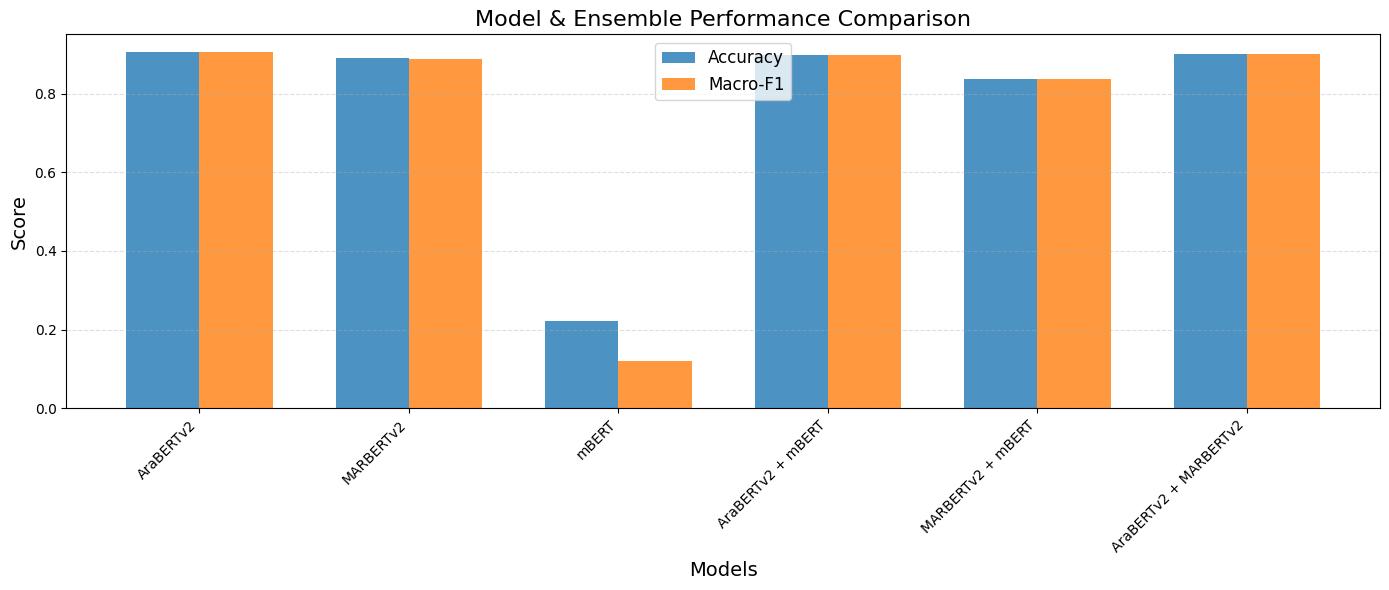

In [51]:

# Plot model comparison (Accuracy & Macro-F1)

import matplotlib.pyplot as plt
import numpy as np

# Extract values
models = model_comparison_df['Model/Ensemble']
accuracy = model_comparison_df['Accuracy']
macro_f1 = model_comparison_df['Macro F1']

x = np.arange(len(models))
width = 0.35  # width of the bars

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, accuracy, width, label='Accuracy', alpha=0.8)
plt.bar(x + width/2, macro_f1, width, label='Macro-F1', alpha=0.8)

# Title & labels
plt.title("Model & Ensemble Performance Comparison", fontsize=16)
plt.xlabel("Models", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.xticks(x, models, rotation=45, ha="right")

# Grid + legend
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


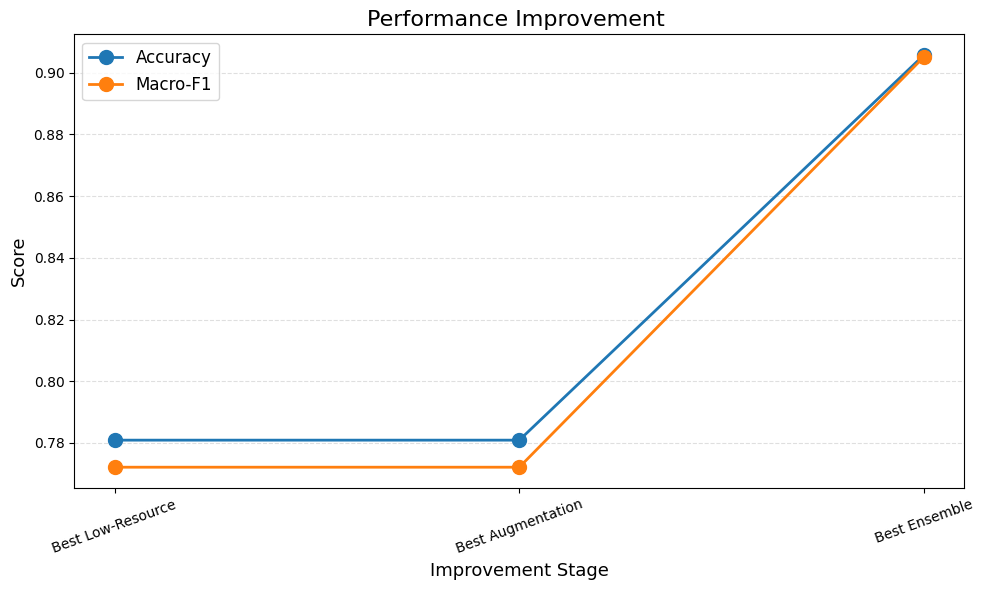

In [63]:
import matplotlib.pyplot as plt
import numpy as np


# 1Extract values ONLY from  improvements


# Best Low-Resource results (use your actual variables)
best_low_acc = max(
    res_20_clean["eval_accuracy"],
    res_20_sim_c["eval_accuracy"],
    res_20_sim_s["eval_accuracy"],
    res_20_sim_k["eval_accuracy"]
)

best_low_f1 = max(
    res_20_clean["eval_macro_f1"],
    res_20_sim_c["eval_macro_f1"],
    res_20_sim_s["eval_macro_f1"],
    res_20_sim_k["eval_macro_f1"]
)

# Best Augmentation (already in aug_table)
best_aug_acc = aug_table["Test Accuracy"].max()
best_aug_f1  = aug_table["Test Macro F1"].max()

# Best Ensemble (already in model_comparison_df)
best_ens_acc = model_comparison_df["Accuracy"].max()
best_ens_f1  = model_comparison_df["Macro F1"].max()

# Prepare data


steps = ["Best Low-Resource", "Best Augmentation", "Best Ensemble"]

accuracy_values = [best_low_acc, best_aug_acc, best_ens_acc]
f1_values       = [best_low_f1,  best_aug_f1,  best_ens_f1]

x = np.arange(len(steps))


# Scatter-Line Plot


plt.figure(figsize=(10,6))

# Accuracy line
plt.plot(
    x, accuracy_values,
    marker="o", markersize=10,
    linewidth=2, label="Accuracy"
)

# Macro-F1 line
plt.plot(
    x, f1_values,
    marker="o", markersize=10,
    linewidth=2, label="Macro-F1"
)

plt.title("Performance Improvement ", fontsize=16)
plt.xlabel("Improvement Stage", fontsize=13)
plt.ylabel("Score", fontsize=13)

plt.xticks(x, steps, rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()


# Create a ZIP file containing all experiment results

In [62]:
import shutil
import os




# Name of the final ZIP file (without extension)
zip_filename = "all_experiments_results"

# Remove old ZIP file if it exists
if os.path.exists(zip_filename + ".zip"):
    os.remove(zip_filename + ".zip")

# Identify all result folders (folders starting with "results_")
folders_to_zip = [f for f in os.listdir() if f.startswith("results_")]

print("Detected result folders:")
for f in folders_to_zip:
    print(" -", f)

# Create a temporary directory to collect all result folders
os.makedirs("all_results_temp", exist_ok=True)

# Copy each results folder into the temporary directory
for folder in folders_to_zip:
    shutil.copytree(folder, f"all_results_temp/{folder}")

# Compress the temporary directory into a single ZIP file
shutil.make_archive(zip_filename, 'zip', "all_results_temp")

print("\n All results successfully zipped into:", zip_filename + ".zip")


Detected result folders:
 - results_arabert_100pct
 - results_arabert_20_clean
 - results_arabert_20_sim_c
 - results_arabert_50pct
 - results_mbert
 - results_arabert_20pct
 - results_marbert
 - results_arabert_20_sim_k
 - results_arabert_20_sim_s

✅ All results successfully zipped into: all_experiments_results.zip
